In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scgraph.geographs.us_freeway import us_freeway_geograph
from sklearn.calibration import CalibratedClassifierCV
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import log_loss, roc_auc_score, brier_score_loss, classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier

In [3]:
path = r"C:\Users\bhavy\Massachusetts Institute of Technology\Truck Parking Capstone - General\Truck Stop Finder 🚚⛽\\"
# path = r"C:\Users\samcl\Massachusetts Institute of Technology\Truck Parking Capstone - Truck Stop Finder 🚚⛽\\"

In [4]:
# Sourced directly from TruckerPath
park_data_1 = pd.read_csv(
    path + r"5. Source & Refrence Files\0. TruckerPath Data\MIT_2025_High_Volume_Routes_Parking_Data_1 - Copy.csv")
park_data_2 = pd.read_csv(
    path + r"5. Source & Refrence Files\0. TruckerPath Data\MIT_2025_High_Volume_Routes_Parking_Data_2 - Copy.csv")
park_data_3 = pd.read_csv(
    path + r"5. Source & Refrence Files\0. TruckerPath Data\MIT_2025_High_Volume_Routes_Parking_Data_3 - Copy.csv")
park_data = pd.concat([park_data_1, park_data_2, park_data_3], ignore_index=True)

In [5]:
park_data.shape

(1761290, 9)

In [6]:
truck_stop = pd.read_excel("output_excel\Model_Stops_V3.xlsx")

In [7]:
avail_park = park_data[park_data["pin id"].isin(truck_stop["pin id"].unique())].copy()

In [8]:
avail_park["ts_utc"] = pd.to_datetime(avail_park["time(utc)"], utc=True)

In [9]:
print(avail_park["ts_utc"].isna().mean(), "fraction of timestamps failed to parse")
print(avail_park["ts_utc"].min(), "to", avail_park["ts_utc"].max())

0.0 fraction of timestamps failed to parse
2024-11-07 00:00:00+00:00 to 2025-11-07 00:45:01+00:00


In [10]:
avail_park = avail_park[avail_park["parking status"] != 'Paid'].copy()

In [11]:
avail_park.head(2)

,pinname,parking status,time(utc),pinlat,pinlon,pin id,object,city,route_num,ts_utc
0,Rest Area WB,Lots,2024/11/22 22:48:15,30.612343,-86.978559,005b00cc243fb4f39296fa0f16a21482,Rest Area,Milton,10,2024-11-22 22:48:15+00:00
1,Rest Area WB,Lots,2024/11/22 18:51:59,30.612343,-86.978559,005b00cc243fb4f39296fa0f16a21482,Rest Area,Milton,10,2024-11-22 18:51:59+00:00


In [12]:
avail_park["object"].unique()

array(['Rest Area', 'Truck Stops', 'Walmarts', 'Ta', 'Love’s', 'Parking',
       'Pilot', 'Flying J', 'AMBest', 'Fuel', 'One9', 'Petro'],
      dtype=object)

In [13]:
avail_park = avail_park.sort_values(["pin id", "ts_utc"])

In [14]:
avail_park

,pinname,parking status,time(utc),pinlat,pinlon,pin id,object,city,route_num,ts_utc
1353040,Truck Spot Properties,Some,2025/01/15 11:23:23,30.406303,-81.743304,00038787e666dbf59f419128a0ee3a66,Parking,Jacksonville,295,2025-01-15 11:23:23+00:00
1353050,Truck Spot Properties,Some,2025/02/06 13:43:22,30.406303,-81.743304,00038787e666dbf59f419128a0ee3a66,Parking,Jacksonville,295,2025-02-06 13:43:22+00:00
1353025,Truck Spot Properties,Some,2025/08/10 12:23:31,30.406303,-81.743304,00038787e666dbf59f419128a0ee3a66,Parking,Jacksonville,295,2025-08-10 12:23:31+00:00
1353043,Truck Spot Properties,Lots,2025/09/25 19:09:58,30.406303,-81.743304,00038787e666dbf59f419128a0ee3a66,Parking,Jacksonville,295,2025-09-25 19:09:58+00:00
65,Rest Area WB,Lots,2024/11/07 01:02:59,30.612343,-86.978559,005b00cc243fb4f39296fa0f16a21482,Rest Area,Milton,10,2024-11-07 01:02:59+00:00
...,...,...,...,...,...,...,...,...,...,...
1230499,Alpha Truck Center,Lots,2025/07/08 15:51:37,30.324783,-81.765593,ff54a86f51cf791a850133ddc157b364,Parking,Jacksonville,295,2025-07-08 15:51:37+00:00
1230498,Alpha Truck Center,Full,2025/07/10 19:19:07,30.324783,-81.765593,ff54a86f51cf791a850133ddc157b364,Parking,Jacksonville,295,2025-07-10 19:19:07+00:00
1230489,Alpha Truck Center,Full,2025/08/13 13:33:58,30.324783,-81.765593,ff54a86f51cf791a850133ddc157b364,Parking,Jacksonville,295,2025-08-13 13:33:58+00:00
1230493,Alpha Truck Center,Some,2025/08/21 18:39:16,30.324783,-81.765593,ff54a86f51cf791a850133ddc157b364,Parking,Jacksonville,295,2025-08-21 18:39:16+00:00


In [15]:
status_map = {
    "Full": 0,
    "Some": 1,
    "Lots": 2
}

avail_park["status_ord"] = avail_park["parking status"].map(status_map)

In [16]:
LABEL_TOL = pd.Timedelta("60min")  # ±60 min for label lookup
STALE_CUTOFF = pd.Timedelta("6h")  # 6h staleness rule for last_known_status

obs = avail_park[["pin id", "ts_utc", "status_ord", "parking status"]].dropna(subset=["ts_utc", "status_ord"])
# obs = obs.sort_values(["pin id", "ts_utc"])
obs_sorted = obs.dropna(subset=["ts_utc"]).sort_values(["ts_utc", "pin id"]).reset_index(drop=True)

In [17]:
obs_sorted[obs_sorted["ts_utc"] == "2024-11-07 00:30:49+00:00"]

,pin id,ts_utc,status_ord,parking status
167,2a9d121cd9c3a1832bb6d2cc6bd7a8a7,2024-11-07 00:30:49+00:00,0,Full


In [18]:
# ---- 2) Helper A: last observation at or before query time (decision-time features)
def attach_last_obs_before(query_df, time_col="query_ts"):
    """
    query_df must have columns: ['pin id', time_col]
    Returns query_df + last observed status at/before query_ts and staleness.
    """
    q = query_df.copy()
    q[time_col] = pd.to_datetime(q[time_col], utc=True, errors="coerce")
    # q = q.sort_values(["pin id", time_col], ignore_index=True)
    q = q.dropna(subset=[time_col]).sort_values([time_col, "pin id"]).reset_index(drop=True)

    out = pd.merge_asof(
        q,
        obs_sorted.rename(
            columns={"ts_utc": "last_ts", "status_ord": "last_status_ord", "parking status": "last_status_txt"}),
        left_on=time_col,
        right_on="last_ts",
        by="pin id",
        direction="backward",  # <= query time
        allow_exact_matches=True
    )

    out["time_since_last_obs_min"] = (out[time_col] - out["last_ts"]).dt.total_seconds() / 60

    # Apply 6h staleness rule: if too old, treat last_known_status as unknown (but keep staleness numeric)
    too_stale = (out[time_col] - out["last_ts"]) > STALE_CUTOFF
    out.loc[too_stale, ["last_status_ord", "last_status_txt", "last_ts"]] = pd.NA

    return out


# ---- 3) Helper B: nearest observation within ±60 minutes (labels around ETA)
def attach_label_nearest(query_df, time_col="eta_ts"):
    """
    query_df must have columns: ['pin id', time_col]
    Returns query_df + label status closest to eta_ts within ±60 minutes.
    If no observation within tolerance, label fields stay NA.
    """
    q = query_df.copy()
    q[time_col] = pd.to_datetime(q[time_col], utc=True, errors="coerce")
    # q = q.sort_values(["pin id", time_col])
    q = q.dropna(subset=[time_col]).sort_values([time_col, "pin id"]).reset_index(drop=True)

    out = pd.merge_asof(
        q,
        obs_sorted.rename(
            columns={"ts_utc": "label_ts", "status_ord": "label_status_ord", "parking status": "label_status_txt"}),
        left_on=time_col,
        right_on="label_ts",
        by="pin id",
        direction="nearest",
        tolerance=LABEL_TOL,
        allow_exact_matches=True
    )

    out["label_time_error_min"] = (out["label_ts"] - out[time_col]).abs().dt.total_seconds() / 60
    return out


In [19]:
# ---- Settings for the first batch
N_DECISIONS = 500_000  # start here; later you can go 500k / 1M
MIN_TAU = 15  # min travel time in minutes
MAX_TAU = 180  # max travel time in minutes

# 1) Build a "decision pool" from real observed timestamps
#    We sample from actual rows to get realistic t0 distribution.
decision_pool = avail_park[[
    "pin id", "ts_utc", "pinlat", "pinlon", "city", "route_num", "object"
]].dropna(subset=["pin id", "ts_utc"]).copy()

decisions = decision_pool.sample(N_DECISIONS, random_state=0).rename(columns={"ts_utc": "t_obs"}).copy()

In [23]:
rng = np.random.default_rng(0)

# unique stops (destination set)
stops = (
    avail_park[["pin id", "city", "route_num", "object", "pinlat", "pinlon"]]
    .dropna(subset=["pin id", "pinlat", "pinlon"])
    .drop_duplicates(subset=["pin id"])
    .reset_index(drop=True)
)
#
# # timestamp pool (realistic time-of-day / day-of-week distribution)
# t_pool = (
#     avail_park[["ts_utc"]]
#     .dropna()
#     .assign(ts_utc=lambda d: pd.to_datetime(d["ts_utc"], utc=True, errors="coerce"))
#     .dropna()
#     .reset_index(drop=True)
# )

In [24]:
N_DRIVERS = 10

drivers = pd.DataFrame({
    "driver_id": np.arange(N_DRIVERS)
})

# pick a random anchor stop per driver
anchors = stops.sample(N_DRIVERS, replace=True, random_state=2)[["pinlat", "pinlon"]].reset_index(drop=True)

# jitter ~ up to ~0.2 degrees (tune this!). 0.1 deg lat ~ 11km.
jitter_lat = rng.normal(loc=0.0, scale=0.15, size=N_DRIVERS)
jitter_lon = rng.normal(loc=0.0, scale=0.20, size=N_DRIVERS)

drivers["orig_lat"] = anchors["pinlat"] + jitter_lat
drivers["orig_lon"] = anchors["pinlon"] + jitter_lon

In [25]:
# Cross join: each driver paired with every stop
decisions = drivers.merge(decisions, how="cross")

# columns you now have:
# driver_id, t0, orig_lat, orig_lon, pin id, pinlat, pinlon, city, route_num, object
print(decisions.shape)

(5000000, 10)


In [26]:
decisions

,driver_id,orig_lat,orig_lon,pin id,t_obs,pinlat,pinlon,city,route_num,object
0,0,35.160996,-81.634336,d6baf65e0b240ce177cf70da146c8dc8,2025-07-23 15:59:38+00:00,34.232813,-79.802181,Florence,95,Pilot
1,0,35.160996,-81.634336,69307a4b5f719fcb4dd798565db2c28d,2025-11-01 21:57:22+00:00,30.742000,-88.110800,Mobile,65,Love’s
2,0,35.160996,-81.634336,8b4066554730ddfaa0266346bdc1b202,2025-08-30 18:47:48+00:00,32.495786,-82.981690,Dublin,16,Love’s
3,0,35.160996,-81.634336,3a0c6a979d63c53dd0156aa6441049df,2024-12-13 02:27:13+00:00,32.877706,-85.148201,West Point,85,Love’s
4,0,35.160996,-81.634336,ec0f40c389aeef789ce03eb814facc6c,2024-11-07 20:41:13+00:00,34.347462,-83.322320,Carnesville,85,Flying J
...,...,...,...,...,...,...,...,...,...,...
4999995,9,33.001064,-87.116830,206b469d9ef37b260a78ca51f4675d09,2025-01-23 01:31:14+00:00,30.727569,-86.507870,Crestview,10,Rest Area
4999996,9,33.001064,-87.116830,69cb3ea317a32c4e6143e665fdb20b14,2025-03-27 11:22:08+00:00,28.326345,-82.321754,San Antonio,75,Flying J
4999997,9,33.001064,-87.116830,e56954b4f6347e897f954495eab16a88,2025-05-06 19:00:56+00:00,33.929980,-81.078205,Cayce,26,Pilot
4999998,9,33.001064,-87.116830,a4cac83b7ab3f3e76b221edbba6f4b03,2025-02-24 23:47:45+00:00,32.857527,-87.941469,Eutaw,20,Rest Area


In [28]:
# 100 drivers?
print(drivers["driver_id"].nunique())

# t0 looks real?
# print(pd.Series(drivers["t0"]).dt.hour.value_counts().head())

# lat/lon ranges reasonable?
print(drivers[["orig_lat", "orig_lon"]].describe())

10
        orig_lat   orig_lon
count  10.000000  10.000000
mean   32.266594 -85.507589
std     1.668945   2.113402
min    30.191035 -87.659532
25%    30.765487 -87.353906
50%    32.278373 -85.776094
75%    33.440685 -84.467097
max    35.160996 -81.634336


In [29]:
# Unique drivers
drivers_unique = (
    decisions[["driver_id", "orig_lat", "orig_lon"]]
    .drop_duplicates("driver_id")
    .reset_index(drop=True)
)

# Unique stops
stops_unique = (
    decisions[["pin id", "pinlat", "pinlon"]]
    .drop_duplicates("pin id")
    .reset_index(drop=True)
)

# Build coordinate list: drivers first, then stops
coords = []

# Drivers
for _, row in drivers_unique.iterrows():
    coords.append({
        "latitude": row["orig_lat"],
        "longitude": row["orig_lon"]
    })

# Stops
for _, row in stops_unique.iterrows():
    coords.append({
        "latitude": row["pinlat"],
        "longitude": row["pinlon"]
    })

In [30]:
distance_matrix = us_freeway_geograph.distance_matrix(
    coords,
    output_units="mi"
)

In [31]:
D = len(drivers_unique)
S = len(stops_unique)

records = []

for i in range(D):
    for j in range(S):
        records.append({
            "driver_id": drivers_unique.loc[i, "driver_id"],
            "pin id": stops_unique.loc[j, "pin id"],
            "distance_mi": distance_matrix[i][D + j]
        })

distance_df = pd.DataFrame(records)

In [32]:
distance_df

,driver_id,pin id,distance_mi
0,0,d6baf65e0b240ce177cf70da146c8dc8,201.446499
1,0,69307a4b5f719fcb4dd798565db2c28d,525.859246
2,0,8b4066554730ddfaa0266346bdc1b202,326.468785
3,0,3a0c6a979d63c53dd0156aa6441049df,280.192214
4,0,ec0f40c389aeef789ce03eb814facc6c,121.039718
...,...,...,...
7745,9,13385035864b8d00a02e25f6ece0067a,382.343007
7746,9,ba825ea8a40c385c33407ebe566fa1bc,268.535035
7747,9,00038787e666dbf59f419128a0ee3a66,502.655001
7748,9,8e5d5b79456a8e2bc09e54e9e518a5f1,623.071230


In [33]:
print(decisions.shape)
decisions = decisions.merge(
    distance_df,
    on=["driver_id", "pin id"],
    how="left"
)
print(decisions.shape)

(5000000, 10)
(5000000, 11)


In [34]:
decisions

,driver_id,orig_lat,orig_lon,pin id,t_obs,pinlat,pinlon,city,route_num,object,distance_mi
0,0,35.160996,-81.634336,d6baf65e0b240ce177cf70da146c8dc8,2025-07-23 15:59:38+00:00,34.232813,-79.802181,Florence,95,Pilot,201.446499
1,0,35.160996,-81.634336,69307a4b5f719fcb4dd798565db2c28d,2025-11-01 21:57:22+00:00,30.742000,-88.110800,Mobile,65,Love’s,525.859246
2,0,35.160996,-81.634336,8b4066554730ddfaa0266346bdc1b202,2025-08-30 18:47:48+00:00,32.495786,-82.981690,Dublin,16,Love’s,326.468785
3,0,35.160996,-81.634336,3a0c6a979d63c53dd0156aa6441049df,2024-12-13 02:27:13+00:00,32.877706,-85.148201,West Point,85,Love’s,280.192214
4,0,35.160996,-81.634336,ec0f40c389aeef789ce03eb814facc6c,2024-11-07 20:41:13+00:00,34.347462,-83.322320,Carnesville,85,Flying J,121.039718
...,...,...,...,...,...,...,...,...,...,...,...
4999995,9,33.001064,-87.116830,206b469d9ef37b260a78ca51f4675d09,2025-01-23 01:31:14+00:00,30.727569,-86.507870,Crestview,10,Rest Area,340.378366
4999996,9,33.001064,-87.116830,69cb3ea317a32c4e6143e665fdb20b14,2025-03-27 11:22:08+00:00,28.326345,-82.321754,San Antonio,75,Flying J,588.249120
4999997,9,33.001064,-87.116830,e56954b4f6347e897f954495eab16a88,2025-05-06 19:00:56+00:00,33.929980,-81.078205,Cayce,26,Pilot,415.655847
4999998,9,33.001064,-87.116830,a4cac83b7ab3f3e76b221edbba6f4b03,2025-02-24 23:47:45+00:00,32.857527,-87.941469,Eutaw,20,Rest Area,65.942091


In [36]:
# 2) Sample travel time tau (minutes)

decisions["tau_min"] = decisions["distance_mi"] / 55
decisions.rename(columns={"t_obs": "t0"}, inplace=True)

# 3) Compute ETA
decisions["eta_ts"] = decisions["t0"] + pd.to_timedelta(decisions["tau_min"], unit="m")

# 4) Add ETA calendar features (these are allowed; you know ETA at decision time)
decisions["eta_hour"] = decisions["eta_ts"].dt.hour
decisions["eta_day_of_week"] = decisions["eta_ts"].dt.dayofweek  # Monday=0
decisions["eta_month"] = decisions["eta_ts"].dt.month

In [37]:
decisions.head(3)

,driver_id,orig_lat,orig_lon,pin id,t0,pinlat,pinlon,city,route_num,object,distance_mi,tau_min,eta_ts,eta_hour,eta_day_of_week,eta_month
0,0,35.160996,-81.634336,d6baf65e0b240ce177cf70da146c8dc8,2025-07-23 15:59:38+00:00,34.232813,-79.802181,Florence,95,Pilot,201.446499,3.662664,2025-07-23 16:03:17.759817170+00:00,16,2,7
1,0,35.160996,-81.634336,69307a4b5f719fcb4dd798565db2c28d,2025-11-01 21:57:22+00:00,30.742000,-88.110800,Mobile,65,Love’s,525.859246,9.561077,2025-11-01 22:06:55.664632210+00:00,22,5,11
2,0,35.160996,-81.634336,8b4066554730ddfaa0266346bdc1b202,2025-08-30 18:47:48+00:00,32.495786,-82.981690,Dublin,16,Love’s,326.468785,5.935796,2025-08-30 18:53:44.147765346+00:00,18,5,8


In [38]:


# 5) Attach last observation at/before t0 (features)
feat = attach_last_obs_before(
    decisions.rename(columns={"t0": "query_ts"}),
    time_col="query_ts"
).rename(columns={"query_ts": "t0"})

# 6) Attach label near ETA within ±60 minutes
lab = attach_label_nearest(
    feat[["pin id", "eta_ts"]].copy(),
    time_col="eta_ts"
)

# Merge labels back (by row order, since we kept same ordering)
feat["label_ts"] = lab["label_ts"].values
feat["label_status_ord"] = lab["label_status_ord"].values
feat["label_status_txt"] = lab["label_status_txt"].values
feat["label_time_error_min"] = lab["label_time_error_min"].values

# 7) Keep only rows with valid labels
train_batch = feat.dropna(subset=["label_status_ord"]).copy()

print("Decision rows:", len(decisions))
print("Training rows with labels:", len(train_batch))
print("Label coverage:", round(len(train_batch) / len(decisions), 3))

# 8) Keep just the columns we care about for modeling (first version)
train_batch = train_batch[[
    "pin id", "pinlat", "pinlon", "city", "route_num", "object",
    "t0", "tau_min", "eta_ts", "eta_hour", "eta_day_of_week", "eta_month",
    "last_status_ord", "time_since_last_obs_min",
    "label_status_ord", "label_time_error_min"
]].reset_index(drop=True)

train_batch.head()


Decision rows: 5000000
Training rows with labels: 5000000
Label coverage: 1.0


,pin id,pinlat,pinlon,city,route_num,object,t0,tau_min,eta_ts,eta_hour,eta_day_of_week,eta_month,last_status_ord,time_since_last_obs_min,label_status_ord,label_time_error_min
0,bfb92b9b1532b06eb59b21fb4b3a9dd6,32.504011,-85.610166,Notasulga,85,Rest Area,2024-11-07 00:02:21+00:00,5.846884,2024-11-07 00:08:11.813029218+00:00,0,3,11,1.0,0.0,2,0.369512
1,bfb92b9b1532b06eb59b21fb4b3a9dd6,32.504011,-85.610166,Notasulga,85,Rest Area,2024-11-07 00:02:21+00:00,3.021762,2024-11-07 00:05:22.305748350+00:00,0,3,11,1.0,0.0,1,2.694244
2,bfb92b9b1532b06eb59b21fb4b3a9dd6,32.504011,-85.610166,Notasulga,85,Rest Area,2024-11-07 00:02:21+00:00,2.709387,2024-11-07 00:05:03.563238012+00:00,0,3,11,1.0,0.0,1,2.709387
3,bfb92b9b1532b06eb59b21fb4b3a9dd6,32.504011,-85.610166,Notasulga,85,Rest Area,2024-11-07 00:02:21+00:00,4.278699,2024-11-07 00:06:37.721930688+00:00,0,3,11,1.0,0.0,1,2.766133
4,bfb92b9b1532b06eb59b21fb4b3a9dd6,32.504011,-85.610166,Notasulga,85,Rest Area,2024-11-07 00:02:21+00:00,3.063439,2024-11-07 00:05:24.806346564+00:00,0,3,11,1.0,0.0,0,1.777467


In [39]:
train_batch[train_batch["last_status_ord"].isnull()]

,pin id,pinlat,pinlon,city,route_num,object,t0,tau_min,eta_ts,eta_hour,eta_day_of_week,eta_month,last_status_ord,time_since_last_obs_min,label_status_ord,label_time_error_min


In [41]:
train_batch["time_since_last_obs_min"].describe()

count    5000000.0
mean           0.0
std            0.0
min            0.0
25%            0.0
50%            0.0
75%            0.0
max            0.0
Name: time_since_last_obs_min, dtype: float64

In [42]:
print(train_batch["last_status_ord"].value_counts(dropna=False))

last_status_ord
2.0    2202020
1.0    1612430
0.0    1185550
Name: count, dtype: int64


In [43]:
n_all = avail_park["pin id"].nunique()
n_train = train_batch["pin id"].nunique()
print("Stops in raw data:", n_all)
print("Stops in training batch:", n_train)
print("Coverage:", n_train / n_all)


Stops in raw data: 786
Stops in training batch: 775
Coverage: 0.9860050890585241


In [44]:
df = train_batch.copy()

In [45]:
df["y_full"] = (df["label_status_ord"] == 0).astype(int)
df = df.sort_values("t0").reset_index(drop=True)
cut = df["t0"].quantile(0.80)  # last 20% time as test (you can change later)
train_df = df[df["t0"] <= cut].copy()
test_df = df[df["t0"] > cut].copy()

In [46]:
print("Train rows:", len(train_df), "Test rows:", len(test_df))
print("Train Full rate:", train_df["y_full"].mean().round(3), "Test Full rate:", test_df["y_full"].mean().round(3))
print("Time split cutoff:", cut)

Train rows: 4000000 Test rows: 1000000
Train Full rate: 0.239 Test Full rate: 0.228
Time split cutoff: 2025-08-20 22:06:50+00:00


In [47]:
num_features = ["last_status_ord", "time_since_last_obs_min", "eta_hour", "eta_day_of_week", "eta_month"]
cat_features = ["route_num"]  # add "city" later if you want

In [48]:
X_train = train_df[num_features + cat_features]
y_train = train_df["y_full"]

X_test = test_df[num_features + cat_features]
y_test = test_df["y_full"]

In [49]:
numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [50]:
preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_features),
        ("cat", categorical_pipe, cat_features)
    ],
    remainder="drop"
)

In [51]:
clf = LogisticRegression(
    max_iter=2000,
    # class_weight="balanced",   # helps if Full is rarer
    solver="lbfgs"
)

In [52]:
base_model = Pipeline(steps=[
    ("prep", preprocess),
    ("clf", clf)
])

In [53]:
# ---- Create a calibration split inside train (time-based)
train_df = train_df.sort_values("t0").reset_index(drop=True)
cal_cut = train_df["t0"].quantile(0.80)  # last 20% of TRAIN becomes calibration set

fit_df = train_df[train_df["t0"] <= cal_cut].copy()
cal_df = train_df[train_df["t0"] > cal_cut].copy()

X_fit, y_fit = fit_df[num_features + cat_features], fit_df["y_full"]
X_cal, y_cal = cal_df[num_features + cat_features], cal_df["y_full"]

print("\nFit rows:", len(fit_df), "Cal rows:", len(cal_df))
print("Fit Full rate:", round(y_fit.mean(), 3), "Cal Full rate:", round(y_cal.mean(), 3))
print("Calibration cutoff:", cal_cut)


Fit rows: 3200000 Cal rows: 800000
Fit Full rate: 0.241 Cal Full rate: 0.235
Calibration cutoff: 2025-06-20 23:22:52.600000+00:00


In [54]:
# ---- 5) Train
base_model.fit(X_fit, y_fit)

calibrated_model = CalibratedClassifierCV(base_model, method="sigmoid", cv="prefit")
calibrated_model.fit(X_cal, y_cal)

C:\Users\bhavy\miniconda3\envs\truck_cap_2\lib\site-packages\sklearn\calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


,estimator,Pipeline(step..._iter=2000))])
,method,'sigmoid'
,cv,'prefit'
,n_jobs,None
,ensemble,'auto'
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False


In [55]:
# ---- Evaluate on test
p_base = np.full_like(y_test, fill_value=y_train.mean(), dtype=float)

p_uncal = base_model.predict_proba(X_test)[:, 1]
p_cal = calibrated_model.predict_proba(X_test)[:, 1]

print("\nTEST metrics:")
print("Baseline  LogLoss:", round(log_loss(y_test, p_base), 4), "Brier:", round(brier_score_loss(y_test, p_base), 4),
      "AUC:", round(roc_auc_score(y_test, p_base), 4))
print("Uncal LR  LogLoss:", round(log_loss(y_test, p_uncal), 4), "Brier:", round(brier_score_loss(y_test, p_uncal), 4),
      "AUC:", round(roc_auc_score(y_test, p_uncal), 4))
print("Cal LR    LogLoss:", round(log_loss(y_test, p_cal), 4), "Brier:", round(brier_score_loss(y_test, p_cal), 4),
      "AUC:", round(roc_auc_score(y_test, p_cal), 4))


TEST metrics:
Baseline  LogLoss: 0.5372 Brier: 0.1761 AUC: 0.5
Uncal LR  LogLoss: 0.4903 Brier: 0.1574 AUC: 0.6934
Cal LR    LogLoss: 0.4903 Brier: 0.1576 AUC: 0.6934


In [56]:
# Optional: confusion matrix at threshold 0.5 for calibrated probs
pred = (p_cal >= 0.5).astype(int)
print("\nConfusion matrix @0.5 (calibrated):")
print(confusion_matrix(y_test, pred))
print("\nClassification report @0.5 (calibrated):")
print(classification_report(y_test, pred, digits=3))


Confusion matrix @0.5 (calibrated):
[[743948  28067]
 [199306  28679]]

Classification report @0.5 (calibrated):
              precision    recall  f1-score   support

           0      0.789     0.964     0.867    772015
           1      0.505     0.126     0.201    227985

    accuracy                          0.773   1000000
   macro avg      0.647     0.545     0.534   1000000
weighted avg      0.724     0.773     0.716   1000000



In [57]:
# baseline probability = always predict train Full rate
p_base = np.full_like(y_test, fill_value=y_train.mean(), dtype=float)

print("Baseline log loss:", log_loss(y_test, p_base))
print("Baseline Brier   :", brier_score_loss(y_test, p_base))


Baseline log loss: 0.5371923381271408
Baseline Brier   : 0.17613829614806245


In [58]:
xgb = XGBClassifier(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    min_child_weight=1.0,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

In [59]:
base_model = Pipeline(steps=[("prep", preprocess), ("clf", xgb)])

In [60]:
base_model.fit(X_fit, y_fit)

,steps,"[('prep', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [61]:
cal_model = CalibratedClassifierCV(base_model, method="sigmoid", cv="prefit")
cal_model.fit(X_cal, y_cal)

C:\Users\bhavy\miniconda3\envs\truck_cap_2\lib\site-packages\sklearn\calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


,estimator,"Pipeline(step...=None, ...))])"
,method,'sigmoid'
,cv,'prefit'
,n_jobs,None
,ensemble,'auto'
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False


In [62]:
# ---------- 3) Evaluate ----------
p_uncal = base_model.predict_proba(X_test)[:, 1]
p_cal = cal_model.predict_proba(X_test)[:, 1]

print("Time cutoff (train/test):", cut)
print("Calibration cutoff (fit/cal):", cal_cut)
print("\nTEST metrics:")
print("Baseline  LogLoss:", round(log_loss(y_test, p_base), 4),
      "Brier:", round(brier_score_loss(y_test, p_base), 4),
      "AUC:", round(roc_auc_score(y_test, p_base), 4))
print("XGB uncal LogLoss:", round(log_loss(y_test, p_uncal), 4),
      "Brier:", round(brier_score_loss(y_test, p_uncal), 4),
      "AUC:", round(roc_auc_score(y_test, p_uncal), 4))
print("XGB cal   LogLoss:", round(log_loss(y_test, p_cal), 4),
      "Brier:", round(brier_score_loss(y_test, p_cal), 4),
      "AUC:", round(roc_auc_score(y_test, p_cal), 4))

Time cutoff (train/test): 2025-08-20 22:06:50+00:00
Calibration cutoff (fit/cal): 2025-06-20 23:22:52.600000+00:00

TEST metrics:
Baseline  LogLoss: 0.5372 Brier: 0.1761 AUC: 0.5
XGB uncal LogLoss: 0.4588 Brier: 0.1474 AUC: 0.7579
XGB cal   LogLoss: 0.4617 Brier: 0.1481 AUC: 0.7579


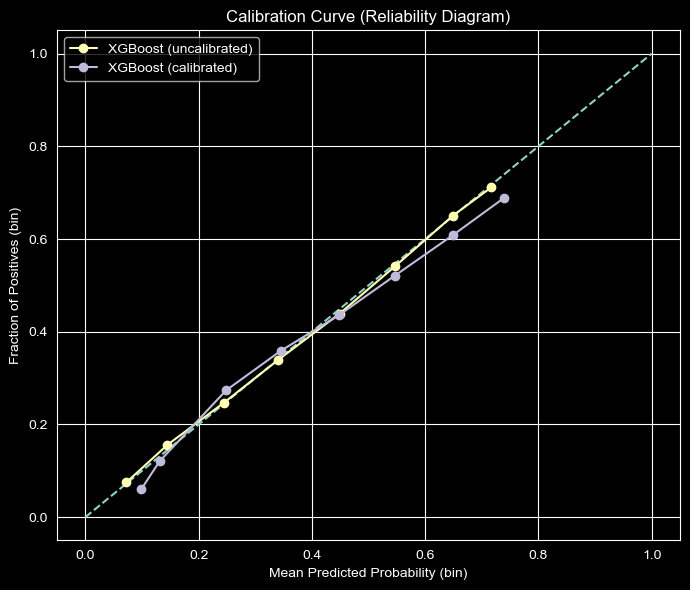

In [63]:

# ---------- 4) Calibration curve plot (reliability diagram) ----------
# Using sklearn.calibration.calibration_curve (like the link you shared)
n_bins = 10
frac_pos_uncal, mean_pred_uncal = calibration_curve(y_test, p_uncal, n_bins=n_bins, strategy="uniform")
frac_pos_cal, mean_pred_cal = calibration_curve(y_test, p_cal, n_bins=n_bins, strategy="uniform")

plt.figure(figsize=(7, 6))
# Perfect calibration line
plt.plot([0, 1], [0, 1], linestyle="--")

# Model curves
plt.plot(mean_pred_uncal, frac_pos_uncal, marker="o", label="XGBoost (uncalibrated)")
plt.plot(mean_pred_cal, frac_pos_cal, marker="o", label="XGBoost (calibrated)")

plt.title("Calibration Curve (Reliability Diagram)")
plt.xlabel("Mean Predicted Probability (bin)")
plt.ylabel("Fraction of Positives (bin)")
plt.legend()
plt.tight_layout()
plt.show()

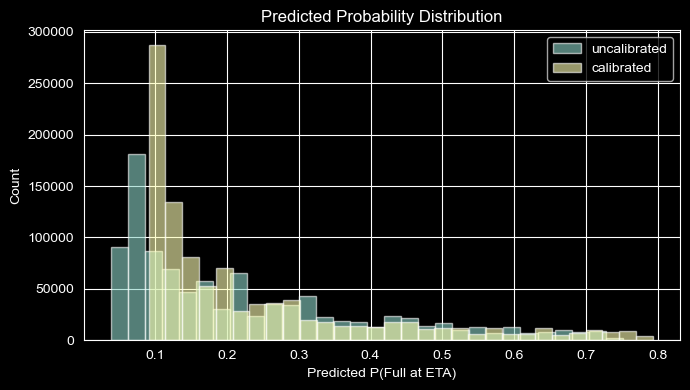

In [64]:
# Optional: histogram of predicted probabilities (helps explain threshold behavior)
plt.figure(figsize=(7, 4))
plt.hist(p_uncal, bins=30, alpha=0.6, label="uncalibrated")
plt.hist(p_cal, bins=30, alpha=0.6, label="calibrated")
plt.title("Predicted Probability Distribution")
plt.xlabel("Predicted P(Full at ETA)")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

In [65]:
thresholds = np.arange(0.05, 0.41, 0.05)

rows = []
for t in thresholds:
    pred = (p_uncal >= t).astype(int)
    tp = ((pred == 1) & (y_test == 1)).sum()
    fp = ((pred == 1) & (y_test == 0)).sum()
    fn = ((pred == 0) & (y_test == 1)).sum()

    recall = tp / (tp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0

    rows.append((t, recall, precision))

pd.DataFrame(rows, columns=["threshold", "recall_full", "precision_full"])


,threshold,recall_full,precision_full
0,0.05,0.999956,0.228014
1,0.10,0.888019,0.306451
2,0.15,0.818238,0.345049
3,0.20,0.738869,0.380508
4,0.25,0.648222,0.422298
5,0.30,0.561278,0.459418
6,0.35,0.465531,0.502502
7,0.40,0.404281,0.532695


In [66]:
# AUC curve


Confusion Matrix (rows=true, cols=pred):
[[652832 119183]
 [114548 113437]]


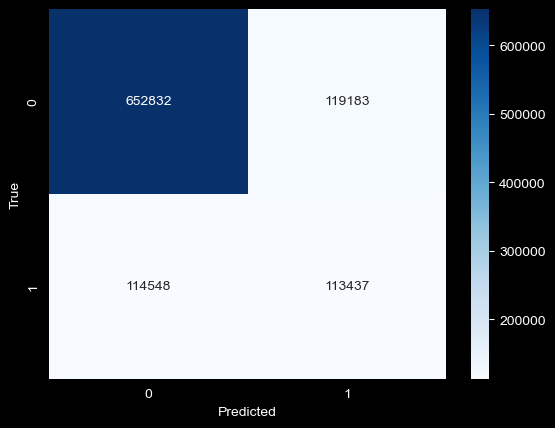

In [67]:
threshold = 0.33
y_pred = (p_uncal >= threshold).astype(int)

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix (rows=true, cols=pred):")
print(cm)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [57]:
def confusion_at_threshold(
        y_true,
        p_pred,
        threshold: float
):
    """
    Compute confusion matrix + key rates at a chosen probability threshold.
    """

    y_hat = (p_pred >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_hat).ravel()

    denominator = np.sqrt(
        (tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))

    phi = (tp * tn - fp * fn) / denominator if denominator > 0 else np.nan

    metrics = {
        "threshold": threshold,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "recall_full": tp / (tp + fn) if (tp + fn) > 0 else np.nan,
        "precision_full": tp / (tp + fp) if (tp + fp) > 0 else np.nan,
        "false_positive_rate": fp / (fp + tn) if (fp + tn) > 0 else np.nan,
        "false_negative_rate": fn / (fn + tp) if (fn + tp) > 0 else np.nan,
        "TNR": tn / (fp + tn) if (fp + tn) > 0 else np.nan,
        "NPV": tn / (tn + fn) if (tn + fn) > 0 else np.nan,
        "FOR": fn / (tn + fn) if (tn + fn) > 0 else np.nan,
        "FDR": fp / (tp + fp) if (tp + fp) > 0 else np.nan,
        "phi": phi

    }

    return metrics, y_hat

In [58]:
range(.05, 1, .1)

TypeError: 'float' object cannot be interpreted as an integer

In [ ]:
threshold = range(5, 100)

df = pd.DataFrame()
for t in threshold:
    t = t / 100
    metrics, y_pred = confusion_at_threshold(
        y_true=y_test,
        p_pred=p_uncal,
        threshold=t
    )

    df = pd.concat([df, pd.DataFrame([metrics])], ignore_index=True)


In [ ]:
df.to_csv("1.csv")

In [68]:
print("Confusion Matrix (rows=true, cols=pred):")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=3))


Confusion Matrix (rows=true, cols=pred):
[[652832 119183]
 [114548 113437]]

Classification Report:
              precision    recall  f1-score   support

           0      0.851     0.846     0.848    772015
           1      0.488     0.498     0.493    227985

    accuracy                          0.766   1000000
   macro avg      0.669     0.672     0.670   1000000
weighted avg      0.768     0.766     0.767   1000000

